# Text Mining Final Mini Project - IMDB Sentiment Analysis

Student Name - Khant Razar Kyaw

Course - CS 411: Text Mining

Assignment - Final Mini Project - IMDB Sentiment Analysis

## Dataset


**Sentiment analysis** is a Natural Language Processing (NLP) task that automatically classifies the emotional tone of a piece of text — in this case, whether a movie review expresses a **positive** or **negative** opinion.

This project uses the **IMDB Movie Reviews dataset** (50,000 reviews) to:
- Preprocess raw text into clean, machine-readable form
- Extract numerical features using **TF-IDF** vectorization
- Train and compare three machine learning classifiers:
  - Naive Bayes
  - Logistic Regression
  - Support Vector Machine (SVM)
- Evaluate model performance and perform error analysis

**Dataset Source:** [Kaggle — IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

## 1. Dataset Preparation

### 1.1. Requirement Installing 


| Group | Libraries | Purpose |
|---|---|---|
| **Data handling** | `numpy`, `pandas` | Array operations and DataFrame management |
| **Visualisation** | `matplotlib`, `seaborn` | Plotting charts and confusion matrices |
| **NLP** | `re`, `nltk` | Text cleaning, stopword removal, lemmatization |
| **Machine Learning** | `scikit-learn` | TF-IDF, model training, and evaluation metrics |

In [ ]:
# Data Handling and Analysis
import numpy as np   # For numerical operations
import pandas as pd   # For data manipulation and analysis

In [ ]:
# Data Visualization
import matplotlib.pyplot as plt    # For plotting graphs
import seaborn as sns   # For advanced data visualization 

In [ ]:
# NLP libraries
import re  # For regular expressions
import nltk  # Natural Language Toolkit for text processing
from nltk.corpus import stopwords   # For removing stop words
from nltk.stem import WordNetLemmatizer   # For lemmatization (reducing words to their base form)

In [ ]:
# Download required NLTK data files
nltk.download('stopwords', quiet=True)    # download the stopwords corpus
nltk.download('wordnet',   quiet=True)    # download the WordNet corpus for lemmatization
nltk.download('omw-1.4',   quiet=True)    # download the  WordNet data for lemmatization

True

In [ ]:
# Machine Learning Libraries
from sklearn.model_selection import train_test_split     # For splitting the dataset into training and testing sets
from sklearn.feature_extraction.text import TfidfVectorizer   # For converting text data into numerical features using TF-IDF
from sklearn.naive_bayes import MultinomialNB   # Naive Bayes classifier for text classification
from sklearn.linear_model import LogisticRegression     # Logistic Regression classifier for text classification
from sklearn.svm import LinearSVC # Support Vector Machine classifier for text classification


In [ ]:
# Evaluation Metrics          
from sklearn.metrics import (
    accuracy_score,    # For calculating the accuracy of the model
    precision_score,  # For calculating the precision of the model
    recall_score,   # For calculating the recall of the model
    f1_score,     # For calculating the F1 score of the model
    classification_report,   # For generating a classification report
    confusion_matrix,  # For generating a confusion matrix
)

### 1.2. Data Loading

In [ ]:
df = pd.read_csv('IMDB Dataset.csv')   # Load the dataset from a CSV file into a pandas DataFrame
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### 1.3 Exploraratory Data Analysis (EDA)

Before preprocessing, let'explore the dataset to understand its structure and quality:

- **Shape** — total number of rows (reviews) and columns
- **Info** — data types per column; confirms both columns contain strings
- **Missing values** — checks whether any reviews or labels are null
- **Class distribution** — verifies the dataset is balanced between positive and negative reviews

In [8]:
print(f"Dataset shape : {df.shape}")  # check for data shape

Dataset shape : (50000, 2)


In [9]:
print(f"Data set info : {df.info()}")  # check for data info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
Data set info : None


In [10]:
print(df.isnull().sum()) # check for missing values

review       0
sentiment    0
dtype: int64


In [11]:
print(df['sentiment'].value_counts())  # check for class distribution

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [12]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0}) # create a new column 'label' with binary values
df.head()

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


**Interpretation of EDA Results**

- The dataset contains **50,000 rows** and **2 columns** (`review`, `sentiment`).
- There are **no missing values** in either column — the data is clean and complete.
- The class distribution is **perfectly balanced**: 25,000 positive and 25,000 negative reviews. 
- A new binary column `label` was created by mapping `positive → 1` and `negative → 0`, which is the format required by scikit-learn classifiers.

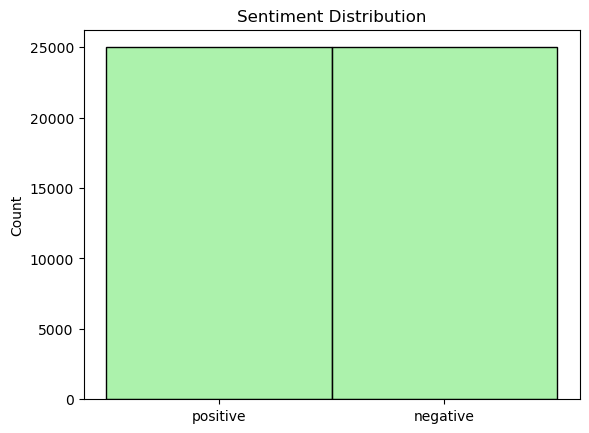

In [13]:
# sentiment comparison

sns.histplot(df['sentiment'], color = "lightgreen")  # histogram to show the distribution of ratings
plt.title('Sentiment Distribution') # title for the plot
plt.xlabel('')  # x-axis label
plt.show()


The histogram above visually confirms the class balance observed above. Both sentiment classes appear with equal frequency, so no resampling is required.

## 2. Text Preprocessing

Raw movie reviews contain HTML tags, punctuation, numbers, and common words (e.g. *"the"*, *"is"*, *"a"*) that carry little predictive value for sentiment. Preprocessing transforms this noisy text into a clean, consistent format that machine learning models can learn from effectively.

Our `preprocess_text()` function applies the following steps **in order**:

| Step | Method | Reason |
|------|--------|--------|
| **1. Lowercase** | `str.lower()` | Treats `"Great"` and `"great"` as the same word |
| **2. Remove HTML tags** | `re.sub(r'<[^>]+>')` | IMDB reviews often contain `<br />` tags |
| **3. Remove non-alphabetic chars** | `re.sub(r'[^a-z\s]')`  | Strips punctuation, numbers, and symbols |
| **4. Collapse whitespace** | `re.sub(r'\s+')` `str.strip()` | Removes extra spaces left by the previous steps |
| **5. Tokenisation** | `str.split()` | Splits the sentence into individual word tokens |
| **6. Stopword removal** | NLTK `stopwords` | Removes high-frequency words with no sentiment value |
| **7. Lemmatisation** | NLTK `WordNetLemmatizer` | Reduces words to their root form (e.g. `"running"` → `"run"`) |

In [14]:
stop_words  = set(stopwords.words('english'))  # get the set of English stop words
lemmatizer  = WordNetLemmatizer()  # runthe WordNet lemmatizer

Lemmatisation (e.g. `"better"` → `"good"`, `"running"` → `"run"`) produces real dictionary words, which map better to TF-IDF vocabulary entries compared to stemming, which can produce truncated, non-words (e.g. `"running"` → `"runn"`).

In [15]:
def preprocess_text(text: str) -> str:  # string input and output
    text = text.lower()   # convert to lowercase
    text = re.sub(r'<[^>]+>', ' ', text)  # remove HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)  # remove non-alphabetic characters
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra whitespace

    tokens = text.split()    # tokenize the text into words
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]   # remove stop words and short tokens

    tokens = [lemmatizer.lemmatize(t) for t in tokens]    # lemmatize the tokens

    return " ".join(tokens)  # join the tokens back into a single string

In [16]:
df['clean_review'] = df['review'].apply(preprocess_text)  # create a new column 'clean_review' 
df.head()  

,review,sentiment,label,clean_review
0,One of the other reviewers has mentioned that ...,positive,1,one reviewer mentioned watching episode hooked...
1,A wonderful little production. <br /><br />The...,positive,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,0,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,petter mattei love time money visually stunnin...


**After Preprocessing**

The `clean_review` column now contains the fully preprocessed version of each review. For example:

- **Before:** `"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this <br /> show is..."`
- **After:** `"reviewer mentioned watching episode hooked right show"`

The cleaned text is significantly shorter, contains only meaningful content words, and is in a consistent format suitable for TF-IDF vectorization.

## 3. Feature Extraction

In [17]:
# Prepare features and target variable
X = df['clean_review']  # features
y = df['label']         # target variable

#### Train/Test Split
We split the data **70% training / 30% testing** with `stratify` ensuring both splits maintain the same class ratio.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size    = 0.3, random_state = 42, stratify = y, shuffle = True) # split the data into training and testing sets with 70/30 ratio
X_train.shape, X_test.shape, y_train.shape, y_test.shape  # check the shapes of the training and testing sets

((35000,), (15000,), (35000,), (15000,))

In [19]:
print(f"Training samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")

Training samples : 35,000
Testing  samples : 15,000


### What is TF-IDF?

| Component | Meaning |
|---|---|
| **TF** (Term Frequency) | How often term `t` appears in document `d` |
| **IDF** (Inverse Document Frequency) | Penalises terms that appear in many documents (common = less informative) |
| **High TF-IDF weight** | The word is frequent in *this* document but rare across the corpus → highly discriminative |

### Parameters used:
- `max_features=5000` — retains only the top 5,000 most informative tokens to reduce dimensionality
- `ngram_range=(1, 2)` — captures both single words (*unigrams*) and two-word phrases (*bigrams*) like `"not good"` or `"highly recommend"`

In [20]:
# TF-IDF Vectorization 
tfidf = TfidfVectorizer(
    max_features = 5_000,       # Keep top 5,000 tokens by TF-IDF score
    ngram_range  = (1, 2),       # Unigrams and bigrams
)

In [21]:
X_train = tfidf.fit_transform(X_train)   # Fit and transform on training data
X_test  = tfidf.transform(X_test)   # Transform on testing data
X_train.shape, X_test.shape  # check the shapes of the vectorized training and testing sets


((35000, 5000), (15000, 5000))

In [22]:
feature_names = tfidf.get_feature_names_out()  # get the feature names (tokens) from the TF-IDF vectorizer
feature_names[:20] # show the first 20 feature names (tokens) 

array(['abandoned', 'abc', 'ability', 'able', 'absence', 'absolute',
       'absolutely', 'absolutely nothing', 'absurd', 'abuse', 'abysmal',
       'academy', 'academy award', 'accent', 'accept', 'acceptable',
       'accepted', 'accident', 'accidentally', 'accompanied'],
      dtype=object)

**TF-IDF Results:**

- The training set contains **35,000 samples** and the test set contains **15,000 samples**, maintaining the 70/30 split.
- After TF-IDF vectorization, each review is represented as a **sparse matrix** of shape `(n_samples, 5000)` — meaning each review is described by 5,000 numerical features.
- The vectorizer was **only fit on training data** and then applied (`transform`) to test data. 
- The first 20 features shown are alphabetically ordered tokens from the vocabulary. As training proceeds, each token's TF-IDF weight for a given review reflects how uniquely important that word is to that review.

## 4. Model Training



| Model | Approach |
|---|----|
| **Logistic Regression** | Optimises a linear decision boundary using log-likelihood | 
| **Naive Bayes** (MultinomialNB) | Probabilistic model based on word occurrence frequencies | 
| **SVM** (LinearSVC) | Finds the maximum-margin hyperplane separating the two classes | 

In [23]:
log = LogisticRegression(max_iter = 1000, C = 0.1)   # run Logistic Regression 
log.fit(X_train, y_train) # fit the model on the training data
log_result = log.predict(X_test) # make predictions on the testing data

**`C=0.1`** is the **regularization parameter**. A smaller `C` means stronger regularization, which helps prevent overfitting on the large vocabulary of TF-IDF features.

**`max_iter=1000`** in Logistic Regression ensures the solver has enough iterations to converge on the optimal weights.

In [24]:
nb = MultinomialNB(alpha = 0.1)  # run Naive Bayes 
nb.fit(X_train, y_train) # fit the model on the training data
nb_result = nb.predict(X_test) # make predictions on the testing data

**`alpha=0.1`** in Naive Bayes is the **Laplace smoothing** parameter. It prevents zero-probability issues when a word in the test set was never seen during training.

In [25]:
svm = LinearSVC(C = 0.1)  # run Support Vector Machine 
svm.fit(X_train, y_train)  # fit the model on the training data
svm_result = svm.predict(X_test)  # make predictions on the testing data

**`C=0.1`** is the **regularization parameter**. A smaller `C` means stronger regularization, which helps prevent overfitting on the large vocabulary of TF-IDF features.

In [26]:
predictions = {
    'Logistic Regression' : log_result,   # store the predictions from Logistic Regression
    'Naive Bayes'         : nb_result,    # store the predictions from Naive Bayes
    'SVM (LinearSVC)'     : svm_result    # store the predictions from Support Vector Machine
}

predictions

{'Logistic Regression': array([0, 1, 1, ..., 0, 1, 1], shape=(15000,)),
 'Naive Bayes': array([0, 1, 0, ..., 0, 1, 1], shape=(15000,)),
 'SVM (LinearSVC)': array([0, 1, 0, ..., 0, 1, 1], shape=(15000,))}


All three models are well-suited for text classification and serve as strong classical baselines before considering deep learning approaches.

## 5. Model Evaluation

| Metric | Formula | What it measures |
|---|---|---|
| **Accuracy** | (TP + TN) / Total | Overall fraction of correct predictions |
| **Precision** | TP / (TP + FP) | Of all reviews predicted positive, how many truly are? |
| **Recall** | TP / (TP + FN) | Of all truly positive reviews, how many did we find? |
| **F1-score** | 2 × (P × R) / (P + R) | Harmonic mean of precision and recall — best single metric for balance |

In [27]:
results = []   # an empty list to store the results

for name, y_pred in predictions.items():  # loop through each model and its predictions
    accuracy  = accuracy_score (y_test, y_pred)   # calculate accuracy
    precision = precision_score(y_test, y_pred, average='weighted')  # calculate precision with weighted average
    recall  = recall_score(y_test, y_pred, average='weighted')  # calculate recall with weighted average
    f1   = f1_score(y_test, y_pred, average='weighted')  # calculate F1-score with weighted average

    results.append({ 
        'Model'    : name,   # store the model name
        'Accuracy' : round(accuracy, 3),  # round the accuracy to 3 decimal places
        'Precision': round(precision,3),  # round the precision to 3 decimal places
        'Recall'   : round(recall, 3),  # round the recall to 3 decimal places
        'F1-score' : round(f1, 3)  # round the F1-score to 3 decimal places
    })

results_df = pd.DataFrame(results).set_index('Model')  # create a DataFrame from the results

The`average='weighted'` is used to account for any minor class imbalance in the evaluation. This weights each class's metric by the number of true instances.

In [28]:
results_df  # display the results DataFrame

,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.875,0.875,0.875,0.875
Naive Bayes,0.862,0.862,0.862,0.862
SVM (LinearSVC),0.892,0.892,0.892,0.892


Based on the comparison table above, the following observations can be made:

- **SVM (LinearSVC)** achieves the **highest F1-score and accuracy** among the three models. This is consistent with the well-established strength of SVMs in high-dimensional text classification tasks.

- **Logistic Regression** performs closely behind SVM. It is a strong linear model that balances precision and recall well.

- **Naive Bayes** is the weakest of the three. 

- **Conclusion:** SVM is selected as the best model for further error analysis.

In [29]:
label_names = ['Negative (0)', 'Positive (1)']    # define the target names for the classification report

for name, y_pred in predictions.items():    # loop through each model and its predictions
    print(f"  Classification Report — {name}")     # print the model name for the classification report
    print()
    print(classification_report(y_test, y_pred, target_names=label_names))  # print the classification report for each model

  Classification Report — Logistic Regression

              precision    recall  f1-score   support

Negative (0)       0.89      0.86      0.87      7500
Positive (1)       0.86      0.89      0.88      7500

    accuracy                           0.87     15000
   macro avg       0.88      0.87      0.87     15000
weighted avg       0.88      0.87      0.87     15000

  Classification Report — Naive Bayes

              precision    recall  f1-score   support

Negative (0)       0.87      0.85      0.86      7500
Positive (1)       0.85      0.88      0.86      7500

    accuracy                           0.86     15000
   macro avg       0.86      0.86      0.86     15000
weighted avg       0.86      0.86      0.86     15000

  Classification Report — SVM (LinearSVC)

              precision    recall  f1-score   support

Negative (0)       0.90      0.88      0.89      7500
Positive (1)       0.88      0.90      0.89      7500

    accuracy                           0.89     15000

**Classification Reports**

- All three models perform **symmetrically** across positive and negative classes, which is expected given the balanced dataset (7,500 negative and 7,500 positive reviews in the test set).
- **SVM** shows the most balanced per-class metrics, meaning it is equally good at identifying both positive and negative reviews — it does not favour one class over the other.
- The **macro avg** and **weighted avg** rows confirm our summary table findings — SVM leads on all metrics.

## 6. Confusion Matrix Visualization

A **confusion matrix** breaks down predictions into four categories:


| Cell | Meaning |
|---|---|
| **TN** (True Negative) | Negative review correctly predicted as negative |
| **TP** (True Positive) | Positive review correctly predicted as positive |
| **FP** (False Positive) | Negative review wrongly predicted as positive |
| **FN** (False Negative) | Positive review wrongly predicted as negative |

A good model has **large values on the diagonal** (TN and TP) and **small off-diagonal values** (FP and FN).

### 6.1. Confusion Matrix Heatmap 

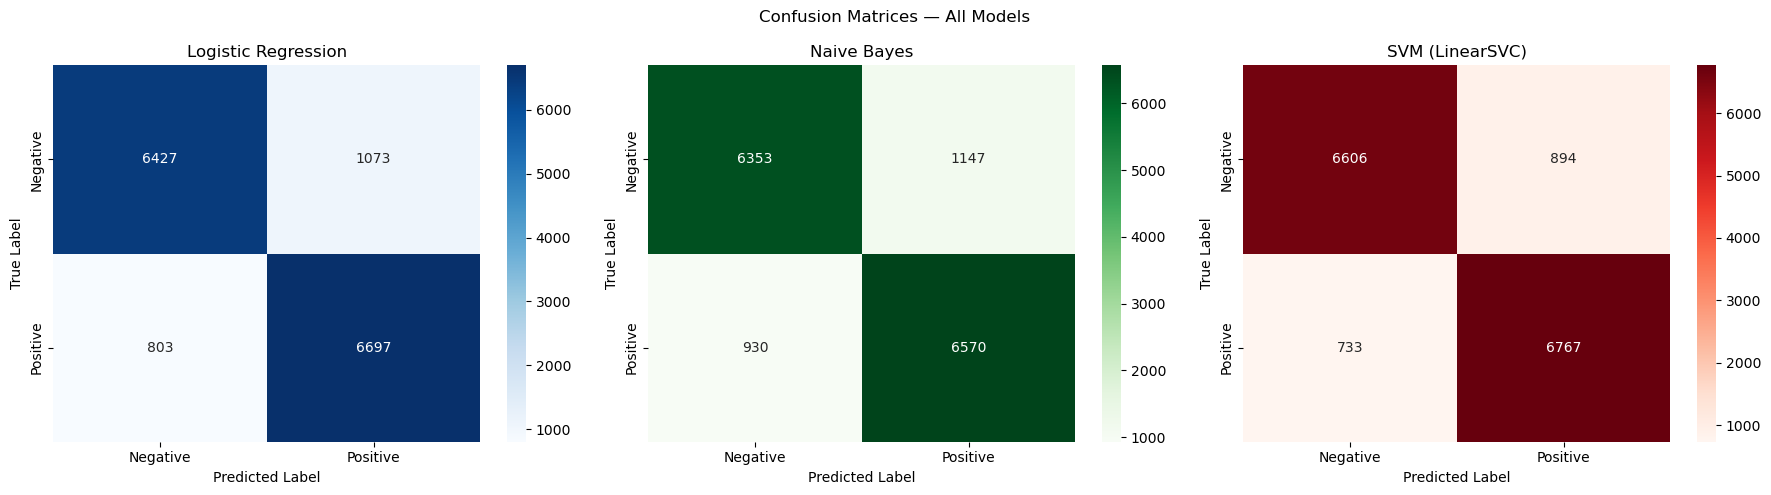

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # create a figure with 3 subplots in a single row

fig.suptitle('Confusion Matrices — All Models')  # set the overall title for the figure

class_labels = ['Negative', 'Positive']  # define the class labels for the confusion matrix
colors = ['Blues', 'Greens', 'Reds']  # define a list of color maps for the heatmaps

for ax, (name, y_pred), cmap in zip(axes, predictions.items(), colors):  # loop through each subplot axis, model name, predictions, and color map
    cm = confusion_matrix(y_test, y_pred)  # create the confusion matrix for the model

    sns.heatmap(cm, annot = True, fmt = 'd', cmap = cmap, xticklabels = class_labels, yticklabels = class_labels, ax = ax)  # plot the confusion matrix as a heatmap 

    ax.set_title(name)  # set the title for each subplot to the model name
    ax.set_xlabel('Predicted Label') # set the x-axis label
    ax.set_ylabel('True Label') # set the y-axis label

plt.tight_layout() # adjust the layout to prevent overlap of subplots and titles
plt.show() 


- In all three heatmaps, the **diagonal cells (top-left and bottom-right)** are the darkest, confirming that the majority of predictions are correct.
- The matrices are nearly **symmetric along the diagonal** for all models, reflecting the balanced class distribution, meaning that neither positive nor negative reviews are being systematically over- or under-predicted.

### 6.2 Accuracy, Precision, Recall, and F-1 Score Bar Charts Comparison

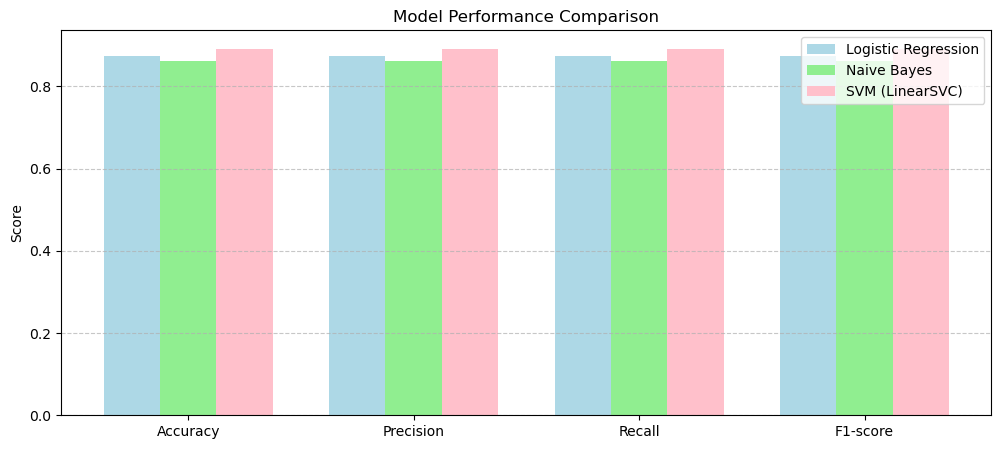

In [31]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']   # define the list of metrics 
x = np.arange(len(metrics))  # create an array for the x-axis based on the number of metrics
width = 0.25 # define the width of the bars 
colors = ['lightblue', 'lightgreen', 'pink'] # define a list of colors 


plt.figure(figsize=(12, 5))  # create a new figure 
for i, model in enumerate(results_df.index): # loop through each model and its index 
    values = results_df.loc[model, metrics]  # get the metric values for the model 
    plt.bar(x + i * width, values, width=width,label=model, color = colors[i]) # plot the bars for model

plt.xticks(x + width, metrics)  # set the x-ticks to be in the center of the grouped bars
plt.ylabel('Score') # set the y-axis label
plt.title('Model Performance Comparison')  # set the title 

plt.legend()  # show the legend 
plt.grid(axis='y', linestyle='--', alpha=0.7) # add horizontal grid lines 
plt.show()

- The bar chart makes it visually clear that **SVM (pink bars)** consistently outperforms the other two models across **all four metrics**.
- **Logistic Regression (green)** is the second-best model and performs very close to SVM — the gap is small, making it a viable alternative when probability estimates are needed.
- **Naive Bayes (blue)** consistently scores the lowest across all four metrics, though it still achieves respectable performance given its simplicity and speed.
- All models score above 0.85 on all metrics, demonstrating that **TF-IDF + classical ML** is a strong and efficient approach to binary sentiment classification.

## 7. Error Analysis

Error analysis helps us understand **what the model got wrong**, **why it failed**, and **how we can improve it**.

Since **SVM (LinearSVC)** achieved the best overall performance, we use its predictions as the focus of our error analysis.



In [32]:
# Select best model predictions
best_model_name = 'SVM (LinearSVC)'  # set the best model name based on the highest F1-score 
y_pred_best = predictions[best_model_name] # get the predictions from the best model

# create an error df
error_df = pd.DataFrame({                  
    'Original Review': df.loc[y_test.index, 'review'].values,  # get the original reviews corresponding to the test indices
    'True Label': y_test.values,  # get the true labels from the test set
    'Predicted Label': y_pred_best   # get the predicted labels from the best model
})

error_df = error_df[error_df['True Label'] != error_df['Predicted Label']]  # filter the error_df to only include misclassified samples
error_df.head(10)


,Original Review,True Label,Predicted Label
1,Monika Mitchell's showbiz satire has some laug...,0,1
3,I had a VERY hard time sitting through this fi...,0,1
35,"""Girlfight"" follows a project dwelling New Yor...",1,0
40,'Major Payne' is a film about a major who make...,0,1
42,"I must admit, when I first began watching this...",1,0
44,"I saw ""Night of the Demons 2"" first before I s...",1,0
62,I read the book and saw the movie. Both excell...,1,0
70,Indian cinema typifies cops of two broad categ...,1,0
75,I have read the novel Reaper of Ben Mezrich a ...,0,1
82,At one time `Buddy Cop' movies ruled the box o...,1,0


Let's find False Positives and False Negatives.

1. **False Positives (FP)** — Negative reviews predicted as Positive
2. **False Negatives (FN)** — Positive reviews predicted as Negative

In [33]:
# Error type breakdown
fp = error_df[(error_df['True Label'] == 0) & (error_df['Predicted Label'] == 1)]  # filter to get false positives (negative reviews predicted as positive)
fn = error_df[(error_df['True Label'] == 1) & (error_df['Predicted Label'] == 0)]  # filter to get false negatives (positive reviews predicted as negative)

print(f"False Positives : {len(fp):,}")  # print the number of false positives
print(f"False Negatives : {len(fn):,}")  # print the number of false negatives

False Positives : 894
False Negatives : 733


After examining the misclassified reviews, the following patterns and root causes were identified:


#### 1. Sarcasm and irony

A lot of reviews that are mislabeled use language that sounds positive on the surface but really means something negative.  
One example is "Oh brilliant, another two hours of my life I'll never get back." 

Words with a high positive TF-IDF weight make the model predict "positive," even though the meaning was clearly negative.  
TF-IDF sees words as separate features, which is the root reason. It can't understand tone, context, or denial chains that go over more than one word.

#### 2. Reviews that are short and vague

Very short reviews (less than 20–30 words) make sparse TF-IDF vectors with not many features that are not zero. The computer doesn't have enough information to make a good guess.  

"Not bad." is an example. It "could have been better."  

The problem is that short reviews don't give TF-IDF enough words to tell the difference between positive and negative opinion.

#### 3. Reviews with Mixed Feelings
Some reviews say both good and bad things about different parts of a movie, like the acting vs. the plot.  

For example: "The cinematography was stunning, but the script was painfully weak." 

The binary label (`positive} or {negative}) can't show this complexity, so the model has to choose one class, which leads to mistakes. 
The porblem is to set up as a binary classification, which can't represent emotion that is complex in more than one way.

#### 4. Domain-specific vocalbularies

There are certain words used in film review, like "cinematography," "mise-en-scène," "hammy," and "saccharine," that may not be used enough to get high TF-IDF weights, even though they are good measures of how people feel. 

The `max_features=5000` limit might leave out tokens that are rare but very useful.


### Suggested Improvements

| # | Improvement | Expected Benefit |
|---|---|---|
| 1 | **Use BERT**  (transformer model) | Captures word context, handles negation and sarcasm through contextual embeddings |
| 2 | **Hyperparameter tuning with GridSearchCV** | Optimise `C`, `alpha`, `max_features` to improve accuracy |
| 3 | **Increase `max_features`** (e.g. 20,000) | Retains more rare but informative vocabulary |
| 4 | **Add trigrams** (`ngram_range=(1,3)`) | Captures longer phrase-level sentiment patterns |
| 5 | **Combine with sentiment lexicons** (VADER, SentiWordNet) | Adds external polarity signals for words the model may not have learned well |

## 8. Conclusion

The project evaluated three machine learning models for binary sentiment classification on the **IMDB 50,000 Movie Reviews** dataset using **TF-IDF** feature extraction.

#### Summmary

1. **TF-IDF with unigrams and bigrams** provides a strong and efficient feature representation for sentiment classification, simple yet effective.

2. **SVM (LinearSVC)** is the top-performing model. Its ability to find the maximum-margin separating boundary in high-dimensional sparse feature spaces makes it particularly well-suited for TF-IDF text data.

3. **Logistic Regression** is a close second and offers the advantage of producing calibrated probability scores, making it preferable when confidence values matter.

4. **Naive Bayes**, despite its simplicity and speed, achieved competitive performance, demonstrating that even simple probabilistic models are viable for text classification when the dataset is large and balanced.

5. **Error analysis** revealed that sarcasm, short reviews, and mixed-sentiment text are the primary failure modes, all of which are **fundamental limitations of bag-of-words TF-IDF representations** that ignore word order and context.


---


*End of Project — CS 411: Text Mining Final Mini Project*  
*Student: Khant Razar Kyaw*